# Posterior exploration: HMC + ArviZ

A point estimate answers "what parameters fit best?" A **posterior** answers the
more useful question: "what parameters are *consistent with the data*, and how
certain are we?" This notebook samples a posterior with **Hamiltonian Monte Carlo
(NUTS)**, exports it as an ArviZ `InferenceData`, and explores it with trace, pair,
and summary diagnostics.

The target is a closed-form ODE likelihood: HIV viral load after therapy starts,
which decays first-order, $V(t) = V_0 e^{-c t}$. Because the model is an exact
expression (no simulator), PyBNF can differentiate it and NUTS can sample it
efficiently. This is the analytical-likelihood surface of tutorial lessons 37–38.

In [1]:
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 80

# HMC needs the optional `jax` extra; ArviZ export needs the `arviz` extra.
import arviz as az
import pybnf_notebook as nb

WORK = Path(tempfile.mkdtemp(prefix='pybnf_posterior_'))
print('arviz', az.__version__)

arviz 1.2.0


## Data from a known truth

$V_0 = 100$, clearance $c = 0.6\,\text{day}^{-1}$, with additive measurement noise.
The `.exp` columns (`time`, `Vobs`) become symbols in the likelihood expression.

In [2]:
V0_true, c_true, sigma = 100.0, 0.6, 2.5
t = np.linspace(0, 8, 20)
rng = np.random.default_rng(2024)
Vobs = V0_true * np.exp(-c_true * t) + rng.normal(0, sigma, t.size)

exp_file = WORK / 'viral_decay.exp'
exp_file.write_text('# time\tVobs\n' + '\n'.join(f'{ti:.6g}\t{vi:.6g}' for ti, vi in zip(t, Vobs)) + '\n')
nb.load_exp(exp_file).head()

,time,Vobs
0,0.000000,102.5720
1,0.421053,81.7802
2,0.842105,63.2015
3,1.263160,44.4323
4,1.684210,32.9207


## Sample the posterior

`objective = expression` turns a math string into a per-point Gaussian negative
log-likelihood (evaluated once per data row and summed). `job_type = hmc` runs
blackjax NUTS across several chains. `output_inference_data = 1` makes PyBNF write a
portable ArviZ `InferenceData` (`Results/inference_data.nc`) alongside the raw
samples. Flat `uniform_var` priors mean the posterior sits at the maximum-likelihood
estimate — swap in `normal_var` for an informative prior and you get a full
Bayesian posterior.

In [3]:
conf = f'''
edition = 2
objective  = expression
expression = 0.5*((Vobs - V0*exp(-c*time))/{sigma})^2
data       = {exp_file}
job_type   = hmc
uniform_var = V0  10   400
uniform_var = c   0.01 3
num_warmup      = 400
num_samples     = 800
population_size = 4
max_iterations  = 1000
random_seed = 2024
output_inference_data = 1
'''
alg = nb.run_fit(conf, WORK / 'out')
print('samples written to', Path(alg.res_dir, 'samples.txt').exists())
print('portable InferenceData written to', Path(alg.res_dir, 'inference_data.nc').exists())

Objective: bring-your-own expression NLL = 0.5*((Vobs - V0*exp(-c*time))/2.5)^2 [binds V0, c; data columns ['Vobs', 'time']].
Note: output_inference_data is set, but objfunc 'chi_sq' is not a per-point likelihood, so no pointwise log-likelihoods are recorded -- the InferenceData will omit the log_likelihood group and az.loo/az.waic will be unavailable. Use a likelihood objfunc (chi_sq, chi_sq_dynamic, lognormal, laplace, neg_bin, neg_bin_dynamic) for LOO/WAIC.


Completed HMC chain 1 of 4 (800 draws, 0 divergent transitions)


Completed HMC chain 2 of 4 (800 draws, 0 divergent transitions)


Completed HMC chain 3 of 4 (800 draws, 0 divergent transitions)


Completed HMC chain 4 of 4 (800 draws, 0 divergent transitions)
Max R-hat: 1.0091
Min bulk ESS: 518.1  Min tail ESS: 662.7
HMC sampling complete: 4 chains x 800 draws written to /var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000bmg/T/pybnf_posterior_3btyi5rk/out/Results/samples.txt
samples written to True
portable InferenceData written to True


## Load the posterior as ArviZ `InferenceData`

Two equivalent routes: read the `.nc` PyBNF wrote (`az.from_netcdf`), or build it
in memory straight from the saved samples with `pybnf.inference_data.from_pybnf`.
Either way you get a first-class ArviZ object.

In [4]:
from pybnf.inference_data import from_pybnf
# Passing the run's free parameters lets the bridge emit each in its sampling space.
idata = from_pybnf(alg.res_dir, variables=alg.variables)
# Equivalently, read the file PyBNF wrote: az.from_netcdf(Path(alg.res_dir, 'inference_data.nc'))
idata.posterior

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  (chain: 4, draw: 800)
    Coordinates:
      * chain    (chain) int64 32B 0 1 2 3
      * draw     (draw) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
    Data variables:
        V0       (chain, draw) float64 26kB 103.2 104.1 104.4 ... 99.78 103.2 103.2
        c        (chain, draw) float64 26kB 0.6209 0.6054 0.6326 ... 0.6341 0.6284
    Attributes:
        created_at:                   2026-07-04T19:15:35.225010+00:00
        creation_library:             ArviZ
        creation_library_version:     1.2.0
        creation_library_language:    Python
        sample_dims:                  ['chain', 'draw']
        inference_library:            pybnf
        created_from:                 /var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000...
        note:                         posterior is the saved (thinned by sample_e...
        pybnf_max_rhat:               1.00908
        pybnf_min_bulk_ess:           518.11
        pybnf_min_tail_ess:           662.73
        pybnf_diagnostics_iteration:  800.0

## Convergence diagnostics: R-hat and ESS

`az.summary` reports the posterior mean/sd, a 94% interval, effective sample sizes
(`ess_bulk`/`ess_tail`), and the Gelman–Rubin `r_hat`. `r_hat ≈ 1.00` and healthy
ESS mean the chains mixed and agree — the sample is trustworthy. The posterior
means land on the truth ($V_0 = 100$, $c = 0.6$).

In [5]:
summary = az.summary(idata)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
V0,102.9,2,100,110,1160,1445,1.00,0.059,0.042
c,0.605,0.0194,0.57,0.64,1140,1609,1.00,0.00057,0.0004


## Trace plots

Each parameter's chains plotted against draw index. Well-mixed chains wander over
the same range and overlap — the "fuzzy caterpillar" look — with no drift or
sticking. That visual agrees with the `r_hat ≈ 1.00` above.

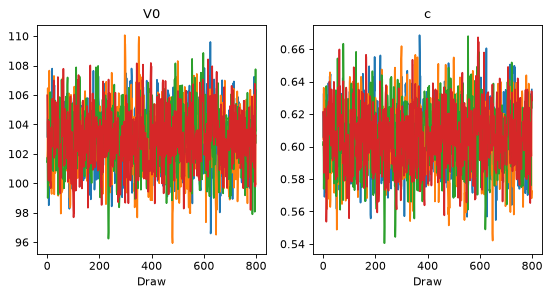

In [6]:
az.plot_trace(idata)
plt.gcf().set_size_inches(7, 3.8); plt.tight_layout(); plt.show()

## The joint posterior

A pair plot shows the *correlation* structure a point estimate hides: the diagonal
holds each parameter's marginal density, the off-diagonal their joint scatter. `V0`
and `c` trade off — a higher initial load can be partly offset by faster clearance —
so the joint posterior is a tilted ellipse rather than a round blob.

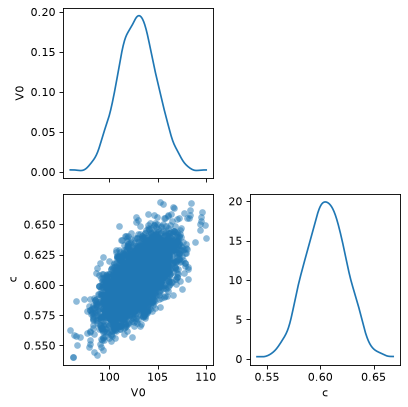

In [7]:
az.plot_pair(idata, marginal=True)
plt.gcf().set_size_inches(5.2, 5.2); plt.tight_layout(); plt.show()

In [8]:
post = idata.posterior
print(f"V0:  posterior mean {float(post['V0'].mean()):6.2f}   (truth {V0_true})")
print(f"c :  posterior mean {float(post['c'].mean()):6.3f}   (truth {c_true})")
print(f"corr(V0, c) = {np.corrcoef(post['V0'].values.ravel(), post['c'].values.ravel())[0,1]:+.2f}")

V0:  posterior mean 102.91   (truth 100.0)
c :  posterior mean  0.605   (truth 0.6)
corr(V0, c) = +0.64


## Takeaways

- `output_inference_data = 1` makes any PyBNF sampler's posterior first-class in the
  ArviZ ecosystem — `az.summary`, `az.plot_trace`, `az.plot_pair`, `az.plot_forest`,
  and friends all work directly.
- For `az.loo` / `az.waic` you need a *per-point likelihood* objective (`chi_sq`,
  `laplace`, `neg_bin`, …) so PyBNF can record the pointwise log-likelihood; the bare
  `expression` target here is scored like `chi_sq` and omits that group (PyBNF says so
  in the run log).
- The same recipe applies to the gradient-free samplers (`dream`, `pt`, `am`) on
  *simulated* models; HMC is special in requiring an analytical/`expression` target.
- Always read `r_hat`/ESS before trusting a posterior; PyBNF also stamps its own
  dense-chain diagnostics into `idata.posterior.attrs` (the `pybnf_*` keys).